## Imports

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypsa
from pypower.loadcase import loadcase
from scipy.io import loadmat
from pymatreader import read_mat

from pathlib import Path
import os
import sys

sys.path.append("../utils")
from matpower_io import load_matpower_case

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import haversine
import geopandas as gpd

# required imports from pypower to match the original matpower implementation.
# replaces "define constants;" line.
import pypower
from pypower.idx_bus  import PD, BUS_AREA
from pypower.idx_gen  import PG, VG, MBASE, GEN_STATUS, PMAX, PMIN
from pypower.idx_brch import BR_X, RATE_A, PF

# pd.set_option("display.max_colwidth", None)  # Show full text (no truncation)  
# pd.set_option("display.width", 1000)  #

## Set paths

In [3]:
tamu_path = Path("../../../2021TXPowerOutage")
eia_path = tamu_path/"From EIA (Generation, Demand, Demand Forecasts, and Interchange by BA)"
case_path = tamu_path/"bte2k/case_Mar3_5pm.mat"
#case_path = tamu_path/"bte2k/hvdc_upgraded.mat"
gen_path = eia_path/"ERCOT Generation by Source/2021-02-01 to 2021-02-19.csv"
#load_path = "eia_path/BES profiles/BES_demand_Feb2021_v20210224.csv"
load_path = eia_path/"ERCOT Demand by Subregion/2021-02-01 to 2021-02-19.csv"
wind_path = eia_path/"BES profiles/BES_wind_Feb2021_v20210224.csv"
solar_path = eia_path/"BES profiles/BES_solar_Feb2016_v20210224.csv"
hydro_path = eia_path/"BES profiles/BES_hydro_Feb2016_v20210224.csv"
lf_path =  eia_path/"ERCOT Demand, Demand Forecast, and Net Interchange/2021-02-01 to 2020-02-19.csv"
# out = "outage"
out_ng_path = tamu_path/"data/unit_outage/ng_outage.csv"
out_pv_path = tamu_path/"data/unit_outage/pv_outage.csv"
out_coal_path = tamu_path/"data/unit_outage/coal_outage.csv"
gen_county_path = tamu_path/"data/unit_outage/gen_county.csv"
ng_derate_path = tamu_path/"data/unit_outage/ng_derate_fac.csv"

out_path = tamu_path/"data/out_mat.mat"
shed_path = tamu_path/"data/shed_mat.mat"
cap_path = tamu_path/"data/ercotcap_mat.mat"
lcf_path = tamu_path/"data/lf_mat.mat"
cty_outage_pct_path = tamu_path/'data/load_outage/cty_out_pct.csv'
cty_outage_dist_path = tamu_path/'data/load_outage/cty_out_dist.csv'
all_bus_cty_path = tamu_path/'data/load_outage/bus_county.csv'

In [ ]:
# create shared index for all timeseries
study_index = pd.date_range("2021-02-01", "2021-02-20", 
                            inclusive='left', 
                            freq='h').tz_localize('US/Central')
study_index

## Load data

In [4]:
out_ts = read_mat(out_path)['out_mat']
shed_ts = read_mat(shed_path)['shed_mat']
cap_ts = read_mat(cap_path)['cap_mat']
lcf_ts = read_mat(lcf_path)['lf_mat']

# the original script has the following line, and I'm not sure why...
shed_ts[:312, 2] = np.nan

In [5]:
# this reads the mpc case directly as a dictionary. 
# I may want to use an alternative method.
mpc = read_mat(case_path)['mpc']

In [6]:
# I'm not sure if I need these since I'm not using matpower. 
# Keeping for reference.
if False:
    mpopt = mpoption('pf.nr.max_it', 50)
    mpopt = mpoption(mpopt,'out.all',0)
    mpopt = mpoption(mpopt,'verbose',0)

In [140]:
def read_ercot_csv(path):
    df = pd.read_csv(path)
    date_parser = lambda date: pd.to_datetime(date.replace("CST",""), 
                                              utc=False).tz_localize("US/Central")
    df['datetime'] = df['Timestamp (Hour Ending)'].apply(date_parser)
    df = df.set_index('datetime')
    df.drop(columns=['Timestamp (Hour Ending)','BA Code'], inplace=True)
    return df

def read_county_df(path):
    out_df = pd.read_csv(path, index_col='UTC')
    out_df.index = pd.to_datetime(out_df.index, utc=False).tz_localize('US/Central')

    # requires globally defined "study index"
    out_df = out_df.reindex(study_index).fillna(0)

    return out_df

In [211]:
load_df

,Coast,East,Far West,North,North Central,South,South Central,West
datetime,,,,,,,,
2021-01-31 00:00:00-06:00,10132,1320,3784,773,9710,2716,5134,1071
2021-01-31 01:00:00-06:00,9785,1241,3718,762,9409,2574,4890,1115
2021-01-31 02:00:00-06:00,9531,1258,3649,752,9376,2440,4745,1246
2021-01-31 03:00:00-06:00,9319,1239,3703,766,9478,2363,4692,1245
2021-01-31 04:00:00-06:00,9138,1263,3826,787,9739,2321,4708,1124
...,...,...,...,...,...,...,...,...
2021-02-17 20:00:00-06:00,9336,2271,1773,1254,19950,3648,9320,1552
2021-02-17 21:00:00-06:00,9765,2293,1765,1232,19638,3656,9334,1569
2021-02-17 22:00:00-06:00,10010,2264,1753,1220,19197,3646,9360,1530


In [213]:
load_df.reindex(study_index).dropna(axis=0)

,Coast,East,Far West,North,North Central,South,South Central,West
2021-02-01 00:00:00-06:00,9881.0,1512.0,3813.0,820.0,11553.0,2647.0,5481.0,1208.0
2021-02-01 01:00:00-06:00,9604.0,1509.0,3800.0,815.0,11275.0,2483.0,5325.0,1202.0
2021-02-01 02:00:00-06:00,9512.0,1512.0,3816.0,825.0,11224.0,2400.0,5281.0,1220.0
2021-02-01 03:00:00-06:00,9511.0,1535.0,3815.0,839.0,11386.0,2378.0,5329.0,1232.0
2021-02-01 04:00:00-06:00,9660.0,1578.0,3844.0,859.0,11679.0,2385.0,5455.0,1262.0
...,...,...,...,...,...,...,...,...
2021-02-17 20:00:00-06:00,9336.0,2271.0,1773.0,1254.0,19950.0,3648.0,9320.0,1552.0
2021-02-17 21:00:00-06:00,9765.0,2293.0,1765.0,1232.0,19638.0,3656.0,9334.0,1569.0
2021-02-17 22:00:00-06:00,10010.0,2264.0,1753.0,1220.0,19197.0,3646.0,9360.0,1530.0
2021-02-17 23:00:00-06:00,10417.0,2221.0,1768.0,1197.0,18673.0,3638.0,9068.0,1542.0


In [207]:
pd.read_csv(load_path)[24:]

,BA Code,Timestamp (Hour Ending),Coast Demand (MWh),East Demand (MWh),Far West Demand (MWh),North Demand (MWh),North Central Demand (MWh),South Demand (MWh),South Central Demand (MWh),West Demand (MWh)
24,ERCO,2/1/2021 12 a.m. CST,9881,1512,3813,820,11553,2647,5481,1208
25,ERCO,2/1/2021 1 a.m. CST,9604,1509,3800,815,11275,2483,5325,1202
26,ERCO,2/1/2021 2 a.m. CST,9512,1512,3816,825,11224,2400,5281,1220
27,ERCO,2/1/2021 3 a.m. CST,9511,1535,3815,839,11386,2378,5329,1232
28,ERCO,2/1/2021 4 a.m. CST,9660,1578,3844,859,11679,2385,5455,1262
...,...,...,...,...,...,...,...,...,...,...
428,ERCO,2/17/2021 8 p.m. CST,9336,2271,1773,1254,19950,3648,9320,1552
429,ERCO,2/17/2021 9 p.m. CST,9765,2293,1765,1232,19638,3656,9334,1569
430,ERCO,2/17/2021 10 p.m. CST,10010,2264,1753,1220,19197,3646,9360,1530
431,ERCO,2/17/2021 11 p.m. CST,10417,2221,1768,1197,18673,3638,9068,1542


In [ ]:
# Read the data into a Pandas DataFrame
gen_df = read_ercot_csv(gen_path)
lf_df = read_ercot_csv(lf_path)
load_df = read_ercot_csv(load_path)
load_df.columns = [col.replace(" Demand (MWh)",'') for col in load_df.columns]
cty_out_dist_df = pd.read_csv(cty_outage_dist_path,
                             index_col='UTC')
cty_out_dist_df.index = pd.to_datetime(cty_out_dist_df.index, utc=False).tz_localize('US/Central')

# read in a list of buses
bus_df = pd.read_csv(all_bus_cty_path, index_col=0)


## Fill in missing data for `cty_out_dist_df`

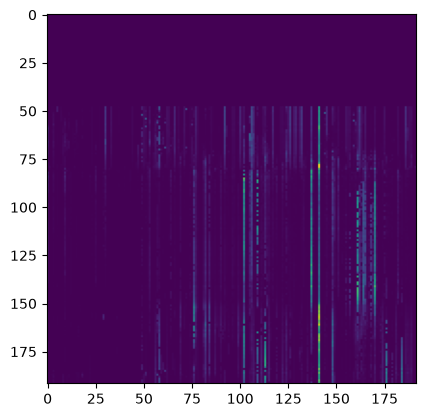

In [11]:
plt.imshow(cty_out_dist_df.values)

In [12]:
outage_ctys = cty_out_dist_df.loc[:,cty_out_dist_df.tail(3).sum(axis=0)>0].columns

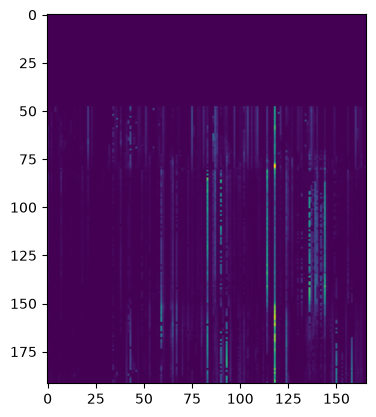

In [13]:
plt.imshow(cty_out_dist_df.loc[:, outage_ctys])

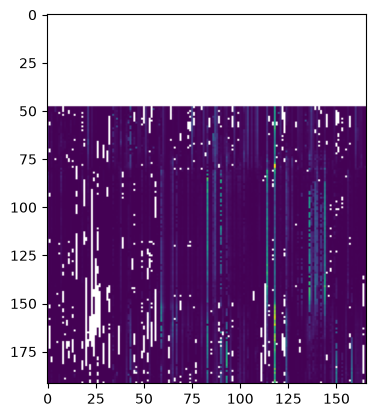

In [14]:
plt.imshow(cty_out_dist_df.loc[:, outage_ctys].replace(0, np.nan))

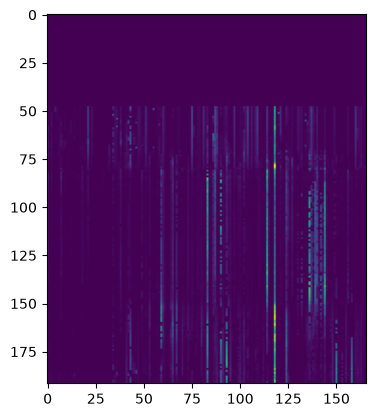

In [15]:
plt.imshow(cty_out_dist_df.loc[:, outage_ctys].replace(0, np.nan).ffill().fillna(0))

In [16]:
# fill in missing data
cty_out_dist_df.loc[:, outage_ctys] = cty_out_dist_df.loc[:, outage_ctys].replace(0, np.nan).ffill().fillna(0)

In [17]:
# normalize each row
cty_out_dist_df = cty_out_dist_df.div(cty_out_dist_df.sum(axis=1),axis=0).fillna(0)

<Axes: xlabel='UTC'>

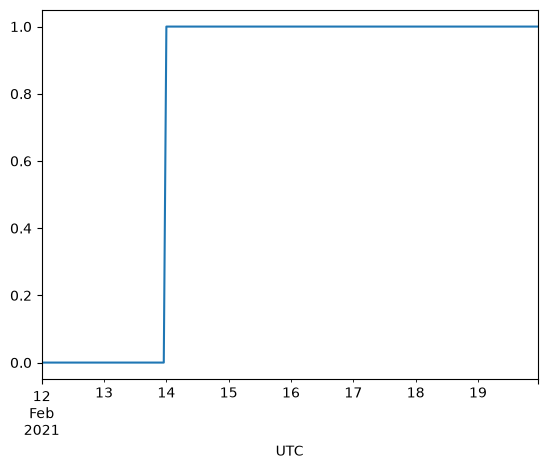

In [18]:
cty_out_dist_df.sum(axis=1).plot()

In [25]:
cty_out_dist_df = cty_out_dist_df.reindex(study_index).fillna(0)

## Create mapping of county outages to bus outages.

In [27]:
bus_county_num = len(cty_out_dist_df.columns)

In [67]:
header_map = {
pypower.idx_bus.BASE_KV:'BASE_KV',
pypower.idx_bus.BS:'BS',
pypower.idx_bus.BUS_AREA:'BUS_AREA',
pypower.idx_bus.BUS_I:'BUS_I',
pypower.idx_bus.BUS_TYPE:'BUS_TYPE',
pypower.idx_bus.GS:'GS',
pypower.idx_bus.LAM_P:'LAM_P',
pypower.idx_bus.LAM_Q:'LAM_Q',
pypower.idx_bus.MU_VMAX:'MU_VMAX',
pypower.idx_bus.MU_VMIN:'MU_VMIN',
# pypower.idx_bus.NONE:'NONE',
pypower.idx_bus.PD:'PD',
# pypower.idx_bus.PQ:'PQ',
# pypower.idx_bus.PV:'PV',
# pypower.idx_bus.QD:'QD',
pypower.idx_bus.REF:'REF',
pypower.idx_bus.VA:'VA',
pypower.idx_bus.VM:'VM',
pypower.idx_bus.VMAX:'VMAX',
pypower.idx_bus.VMIN:'VMIN',
pypower.idx_bus.ZONE:'ZONE'
}

In [71]:
mpc_bus_df = pd.DataFrame(mpc['bus']).rename(columns=header_map)
mpc_bus_df['BUS_I'] = mpc_bus_df['BUS_I'].astype(int)

In [74]:
mpc_bus_df

,BUS_I,BUS_TYPE,PD,REF,GS,BS,BUS_AREA,VM,VA,BASE_KV,ZONE,VMAX,VMIN,LAM_P,LAM_Q,MU_VMAX,MU_VMIN
0,3001001,1.0,20.78,5.89,0.0,0.00,301.0,0.998372,-22.3462,115.0,9.0,1.1,0.9,0.0,0.0,0.0,0.0
1,3001002,1.0,15.41,4.37,0.0,0.00,301.0,1.022910,-17.8585,115.0,9.0,1.1,0.9,0.0,0.0,0.0,0.0
2,3001003,1.0,0.00,0.00,0.0,0.00,301.0,1.014100,-17.5032,115.0,9.0,1.1,0.9,0.0,0.0,0.0,0.0
3,3001004,2.0,0.00,0.00,0.0,0.00,301.0,1.020050,-19.3247,230.0,9.0,1.1,0.9,0.0,0.0,0.0,0.0
4,3001005,1.0,0.00,0.00,0.0,0.00,301.0,1.012380,-15.9276,115.0,9.0,1.1,0.9,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,3008156,1.0,0.00,0.00,0.0,0.00,308.0,1.026110,-46.1097,230.0,7.0,1.1,0.9,0.0,0.0,0.0,0.0
1996,3008157,1.0,0.00,0.00,0.0,0.00,308.0,1.028080,-50.0113,115.0,7.0,1.1,0.9,0.0,0.0,0.0,0.0
1997,3008158,2.0,0.00,0.00,0.0,0.00,308.0,1.026500,-39.4672,500.0,7.0,1.1,0.9,0.0,0.0,0.0,0.0
1998,3008159,1.0,0.00,0.00,0.0,125.36,308.0,1.030000,-42.6388,230.0,7.0,1.1,0.9,0.0,0.0,0.0,0.0


In [121]:
bus_out_dist = np.zeros((len(cty_out_dist_df), len(bus_df)))
for i, curr_cty in enumerate(cty_out_dist_df.columns):
    bus_curr_cty = bus_df['0']==curr_cty
    ratio = mpc_bus_df.loc[bus_curr_cty, "PD"].div(mpc_bus_df.loc[bus_curr_cty, "PD"].sum(),axis=0)
    bus_out_dist[:, bus_curr_cty] = np.outer(cty_out_dist_df.loc[:, curr_cty].to_numpy(), ratio)

In [126]:
bus_out_dist = np.nan_to_num(bus_out_dist, nan=0)

## Create area-level outage distributions

In [135]:
n_areas = len(mpc_bus_df['BUS_AREA'].unique())
n_buses = len(bus_df)
area_out_dist = np.zeros((len(cty_out_dist_df), n_areas))
for a in range(n_buses):
    ar = int(mpc_bus_df.at[a, 'BUS_AREA'] % 300)-1
    area_out_dist[:, ar] += bus_out_dist[:, a]

# area_out_dist = np.divide(area_out_dist, np.sum(area_out_dist,axis=1),axis=0)
area_out_dist = area_out_dist / np.sum(area_out_dist,axis=1, keepdims=True)
area_out_dist = np.nan_to_num(area_out_dist, nan=0)

C:\Users\SDotson\AppData\Local\Temp\ipykernel_2824\4074284160.py:9: RuntimeWarning: invalid value encountered in divide
  area_out_dist = area_out_dist / np.sum(area_out_dist,axis=1, keepdims=True)


## Outage Data By County

In [ ]:
out_ng_df = read_county_df(out_ng_path)
out_pv_df = read_county_df(out_pv_path)
out_coal_df = read_county_df(out_coal_path)
ng_derate_df = read_county_df(ng_derate_path)

county_list = ng_derate_df.columns
county_num = len(county_list)


In [155]:
gen_county_df = pd.read_csv(gen_county_path, index_col=0)

In [159]:
lf_df = lf_df.reindex(study_index)
gen_df = gen_df.reindex(study_index)
load_df = load_df.reindex(study_index)

In [176]:
dcnet_ts = lf_df.iloc[:, 3]

In [171]:
# per the code documentation, they remove the first 6 rows which means the authors knew/believed
# that this dataset was actually in UTC.
wind_ts_df = pd.read_csv(wind_path, index_col='UTC')[6:]
wind_ts_df.index = pd.to_datetime(wind_ts_df.index, utc=True).tz_convert('US/Central')

In [ ]:
# read in representative solar and wind timeseries
# the original data are from 2016 and will be rescaled according
# to EIA actuals.
hydro_ts_df = pd.read_csv(hydro_path, index_col='CST')
hydro_ts_df = hydro_ts_df.reset_index(drop=True)
hydro_ts_df = hydro_ts_df.reindex(range(len(study_index)))
hydro_ts_df = hydro_ts_df.set_index(study_index)

solar_ts_df = pd.read_csv(solar_path, index_col='CST')
solar_ts_df = solar_ts_df.reset_index(drop=True)
solar_ts_df = solar_ts_df.reindex(range(len(study_index)))
solar_ts_df = solar_ts_df.set_index(study_index)

In [196]:
genmix_header = ["wind", "solar", "hydro", "other", "ng", "coal", "nuclear"]

coal_ind = np.where(np.asarray(mpc['genfuel'])=='coal')[0]
pv_ind = np.where(np.asarray(mpc['genfuel'])=='solar')[0]
hydro_ind = np.where(np.asarray(mpc['genfuel'])=='hydro')[0]
ng_ind = np.where(np.asarray(mpc['genfuel'])=='ng')[0]
nuke_ind = np.where(np.asarray(mpc['genfuel'])=='nuclear')[0]
wind_ind = np.where(np.asarray(mpc['genfuel'])=='wind')[0]

In [ ]:
area_mpc = ["FW", "N", "W", "S", "NC", "SC", "C", "E"]
col_names = ["Far West", "North", "West", "South", "North Central", "South Central", "Coast", "East"]
zone_header_map = dict(zip(col_names, area_mpc))

The load df has 433 rows, which is fewer than 456. But if I reindex with the study index
the load is padded with NaNs at the end. The original dataset had a datetime column called "CST,"
which I treated as accurate. But it seems like some of the other datasets with UTC columns were
incorrectly labeled "UTC" -- or at least they're being treated that way. Just something to be
wary of.

I just checked the original matlab code, and they actually removed the first 24 hours of the dataset.
Reindexing by the study index does the same thing, but pads the end. As long as I drop the NaN values
at the end, I should have the same shape and properly aligned data.

In [214]:
load_rearranged = load_df.rename(columns=zone_header_map)[area_mpc].reindex(study_index).dropna(axis=0)

In [218]:
load_rearranged.values

array([[ 3813.,   820.,  1208., ...,  5481.,  9881.,  1512.],
       [ 3800.,   815.,  1202., ...,  5325.,  9604.,  1509.],
       [ 3816.,   825.,  1220., ...,  5281.,  9512.,  1512.],
       ...,
       [ 1753.,  1220.,  1530., ...,  9360., 10010.,  2264.],
       [ 1768.,  1197.,  1542., ...,  9068., 10417.,  2221.],
       [ 1752.,  1193.,  1580., ...,  8976., 10484.,  2190.]],
      shape=(409, 8))

In [ ]:
ect_shed_ttl = lcf_ts[:409, :] - load_rearranged.values
ect_shed = np.nan_to_num(ect_shed_ttl / ect_shed_ttl.sum(axis=1, keepdims=True), nan=0)

C:\Users\SDotson\AppData\Local\Temp\ipykernel_2824\217546379.py:2: RuntimeWarning: invalid value encountered in divide
  ect_shed = np.nan_to_num(ect_shed_ttl / ect_shed_ttl.sum(axis=1, keepdims=True), nan=0)


In [ ]:
lf_df = lf_df.reindex(study_index)
gen_df = gen_df.reindex(study_index)
load_df = load_df.reindex(study_index)

<Axes: >

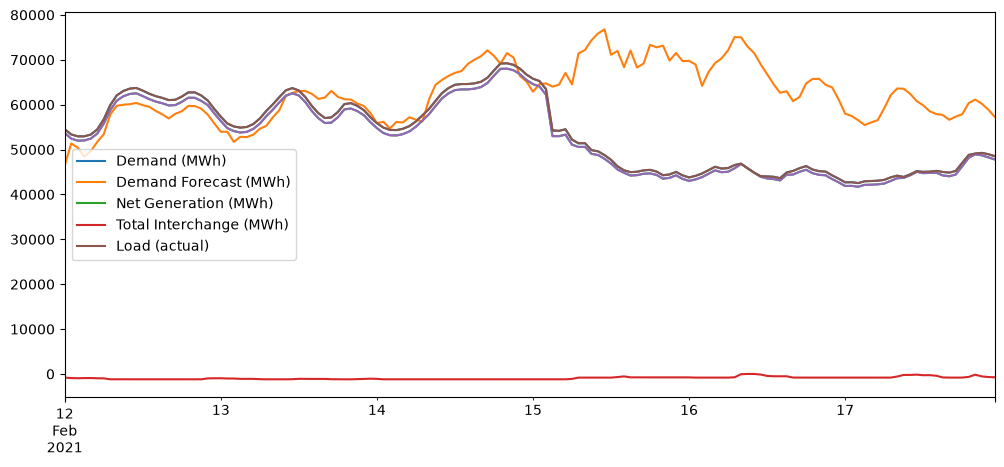

In [14]:
fig, ax = plt.subplots(figsize=(12,5))
lf_df.reindex(study_index).plot(ax=ax)
gen_df.reindex(study_index).sum(axis=1).plot(ax=ax)
load_df.reindex(study_index).sum(axis=1).to_frame().rename({0:'Load (actual)'},axis=1).plot(ax=ax)